# Violencia en Tech — Notebook 06: Análisis Temporal

**Proyecto:** Sistema de Análisis de Violencia Simbólica contra Mujeres en Tecnología  
**Autora:** Maricarmen Camacho Pérez — UAEH, Ciencias Computacionales  
**Input:** `data/processed/reddit_data_clasificado_BERT.csv`  
**Output:** Figuras de análisis temporal para el artículo  

---
**Pipeline:** 01_Extraccion → 02_EDA → 03_Limpieza → 04_Reglas → 05_BERT → **06_Temporal** → Final

---

### ¿Qué hace este notebook?
1. Analiza cómo ha cambiado la violencia simbólica año a año (2016–2026)
2. Calcula una regresión lineal para ver si hay tendencia de aumento o disminución
3. Compara los resultados con eventos históricos (#MeToo, Google Walkout, COVID, etc.)
4. Genera las figuras del artículo (sección 3.5 y 4.3)

---
## 1. Librerías

In [1]:
# ══════════════════════════════════════════════════════════
# IMPORTACIÓN DE LIBRERÍAS
# ══════════════════════════════════════════════════════════

import pandas as pd          # Manipulación de datos
import numpy as np           # Operaciones numéricas
import matplotlib.pyplot as plt      # Gráficas
import matplotlib.patches as mpatches # Leyendas personalizadas
import seaborn as sns        # Gráficas estadísticas
from scipy import stats      # stats.linregress para la regresión lineal
from datetime import datetime
import os
import warnings
warnings.filterwarnings("ignore")

# Colores por categoría (mismos que en todo el proyecto)
PALETTE = {
    "VIOLENCIA_DIRECTA": "#E84E4F",  # Rojo
    "VIOLENCIA_SUTIL":   "#F5A623",  # Naranja
    "NEUTRAL":           "#4CAF50",  # Verde
    "primario":          "#2C5F8A",  # Azul
}

# Estilo global de las gráficas: fondo claro, grid suave
plt.rcParams.update({
    "figure.facecolor": "#F7F9FC",  # Fondo de la figura
    "axes.facecolor":   "#F7F9FC",  # Fondo del área de dibujo
    "axes.grid":        True,        # Mostrar grid
    "grid.alpha":       0.3,         # Grid semitransparente
    "font.size":        11,          # Tamaño de fuente base
})

# Crear carpeta de imágenes si no existe
os.makedirs("../images/resultados", exist_ok=True)

print(f"Análisis temporal iniciado: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Análisis temporal iniciado: 2026-03-18 21:31


---
## 2. Cargar y preparar datos

Se usa la clasificación de BERT (no la de reglas) porque es más precisa.

In [2]:
# ══════════════════════════════════════════════════════════
# CARGAR EL DATASET CLASIFICADO POR BERT
# Este CSV viene del Notebook 05 (Google Colab)
# Contiene todos los textos del corpus con su categoría BERT
# ══════════════════════════════════════════════════════════

df = pd.read_csv("../data/processed/reddit_data_clasificado_BERT.csv")

# Convertir fecha de string a datetime
df["fecha"]   = pd.to_datetime(df["fecha"], utc=True, errors="coerce")
df["año"]     = df["fecha"].dt.year           # Año para agrupar
df["mes"]     = df["fecha"].dt.month           # Mes
df["año_mes"] = df["fecha"].dt.to_period("M")  # Período mensual para timeline

# Usamos la clasificación de BERT (más precisa que las reglas)
# La columna se llama "categoria_BERT" y tiene valores:
# VIOLENCIA_DIRECTA, VIOLENCIA_SUTIL, NEUTRAL
COLUMNA_CAT = "categoria_BERT"

print(f"Dataset: {len(df):,} textos | {df['año'].min()}–{df['año'].max()}")
print(f"\nDistribución (BERT):")
for cat, n in df[COLUMNA_CAT].value_counts().items():
    print(f"  {cat:<22}: {n:>7,} ({n/len(df)*100:.1f}%)")

Dataset: 184,572 textos | 2016–2026

Distribución (BERT):
  NEUTRAL               : 141,566 (76.7%)
  VIOLENCIA_SUTIL       :  21,781 (11.8%)
  VIOLENCIA_DIRECTA     :  21,225 (11.5%)


---
## 3. Calcular tendencias anuales

In [ ]:
# ══════════════════════════════════════════════════════════
# AGRUPAR POR AÑO Y CATEGORÍA
# Esto nos da una tabla cruzada: filas=años, columnas=categorías
# ══════════════════════════════════════════════════════════

# Contar textos por año y categoría
# .unstack() convierte las categorías de filas a columnas
# fill_value=0 pone 0 donde no hay datos
por_año_cat = df.groupby(["año", COLUMNA_CAT]).size().unstack(fill_value=0)

# Calcular porcentaje por año (normalizado)
# Dividir cada fila entre su total y multiplicar por 100
# Esto permite comparar años con diferente volumen de textos
por_año_cat_pct = por_año_cat.div(por_año_cat.sum(axis=1), axis=0) * 100

# ── Calcular porcentaje de violencia total por año ───────
# Violencia total = directa + sutil
violencia_cols = [c for c in ["VIOLENCIA_DIRECTA", "VIOLENCIA_SUTIL"]
                if c in por_año_cat.columns]
violencia_total = por_año_cat[violencia_cols].sum(axis=1)  # Suma directa + sutil
total_año = por_año_cat.sum(axis=1)                        # Total por año
pct_violencia = (violencia_total / total_año * 100)        # Porcentaje

# Mostrar tablas
print("Distribución absoluta por año y categoría:")
print(por_año_cat.to_string())
print("\nDistribución porcentual:")
print(por_año_cat_pct.round(1).to_string())
print(f"\nViolencia total por año (%):")
for año, pct in pct_violencia.items():
    print(f"  {año}: {pct:.1f}%")

Distribución absoluta por año y categoría:
categoria_BERT  NEUTRAL  VIOLENCIA_DIRECTA  VIOLENCIA_SUTIL
año                                                        
2016               4375                747              720
2017               5176                860              827
2018               6598               1176             1132
2019               8125               1124             1298
2020              10380               1671             1760
2021              16138               2551             2433
2022              18967               2738             2616
2023              17013               2489             2312
2024              22490               3371             3878
2025              28839               4051             4337
2026               3465                447              468

Distribución porcentual:
categoria_BERT  NEUTRAL  VIOLENCIA_DIRECTA  VIOLENCIA_SUTIL
año                                                        
2016               74.9        

---
## 4. Visualización de tendencias anuales

Figura con 4 paneles para el artículo (sección 4.3):  
- (A) Volumen absoluto por año y categoría  
- (B) Tendencia de violencia total con regresión lineal  
- (C) Composición porcentual (stacked area)  
- (D) Violencia por subreddit (top 8)


Regresión lineal:
  Pendiente : -0.351% por año
  r²        : 0.55
  p-valor   : 0.0088


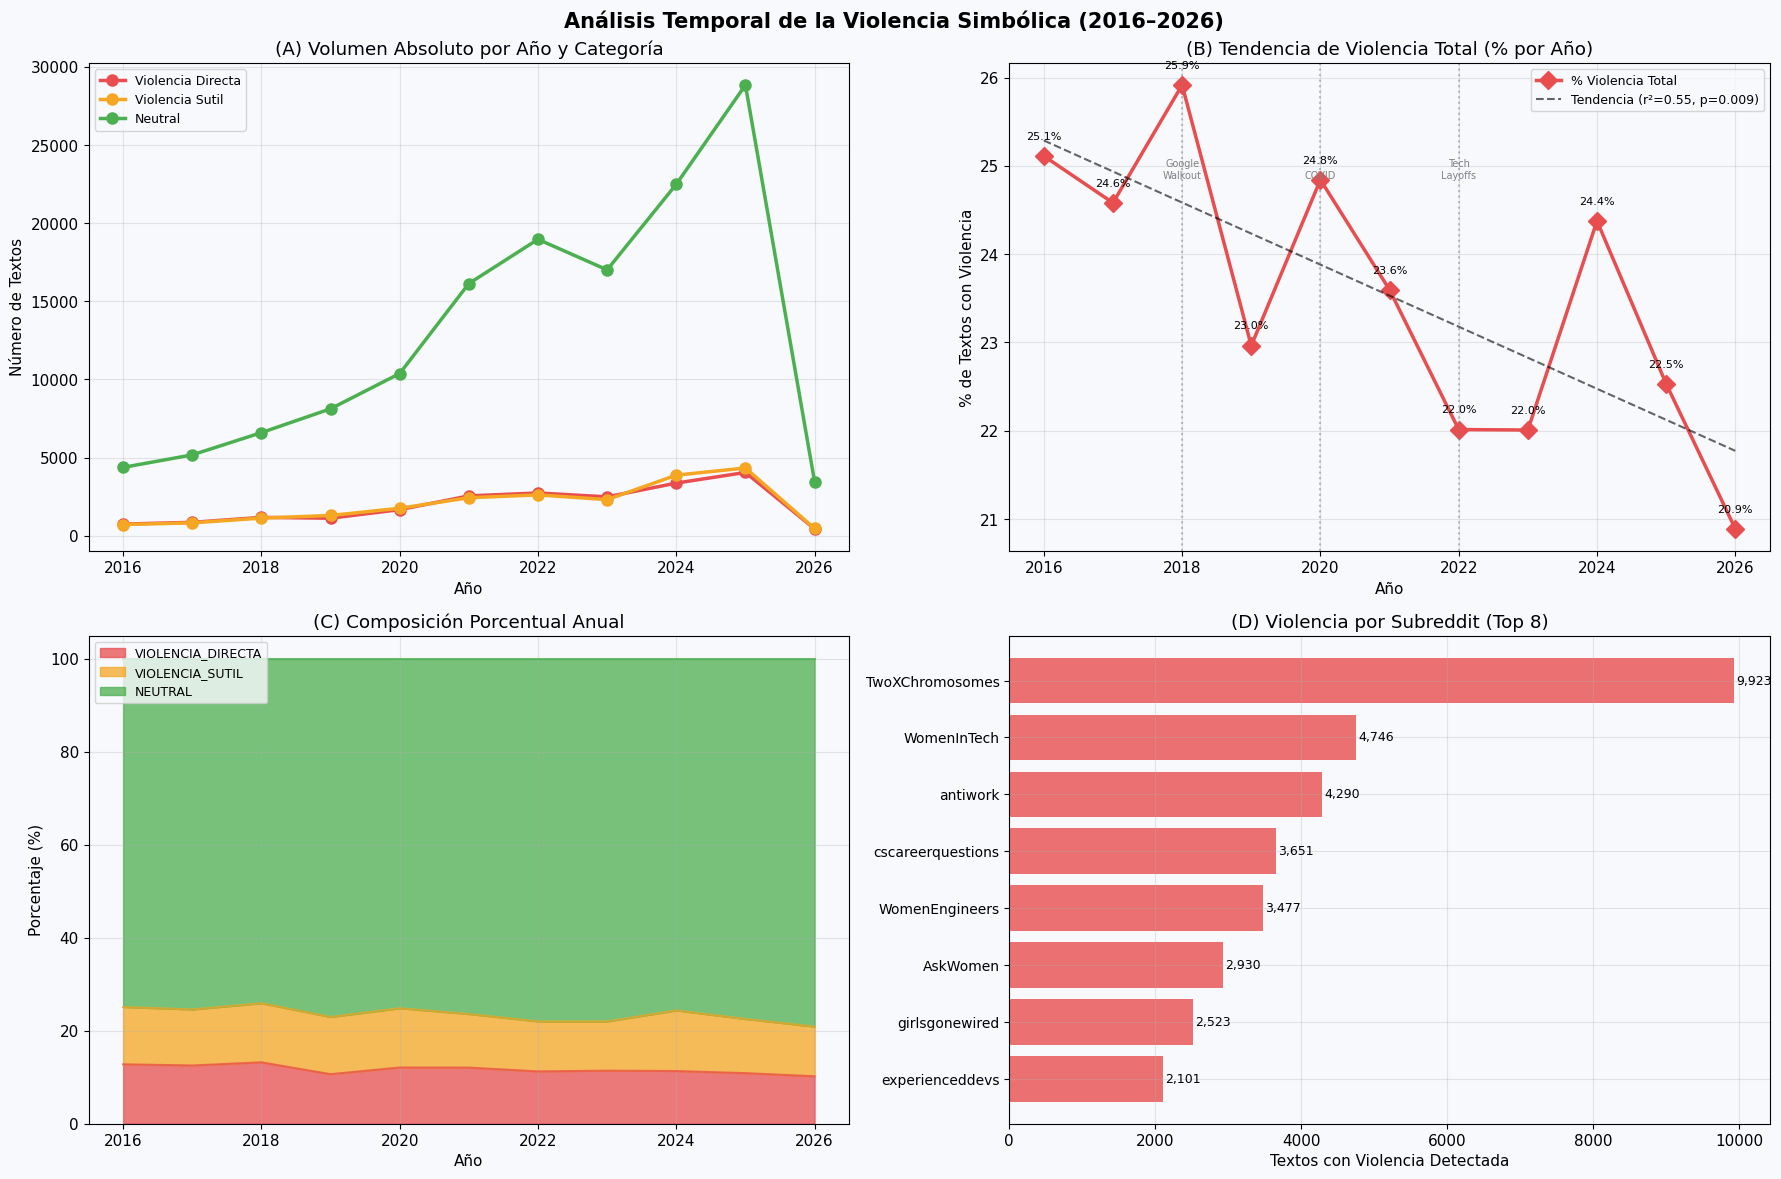

Figura guardada: ../images/resultados/06_tendencias_temporales.png


In [ ]:
# ══════════════════════════════════════════════════════════
# FIGURA PRINCIPAL: 4 PANELES DE ANÁLISIS TEMPORAL
# Esta es la Figura 10 del artículo (sección 4.3)
# ══════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Análisis Temporal de la Violencia Simbólica (2016–2026)",
            fontsize=15, fontweight="bold")

# Lista de categorías que existen en los datos
categorias = [c for c in ["VIOLENCIA_DIRECTA", "VIOLENCIA_SUTIL", "NEUTRAL"]
            if c in por_año_cat.columns]

# ── Panel (A): Volumen absoluto por año ──────────────────
# Muestra cuántos textos hay de cada categoría por año
ax = axes[0, 0]
for cat in categorias:
    ax.plot(por_año_cat.index, por_año_cat[cat],
            marker="o",           # Punto en cada año
            linewidth=2.5,        # Grosor de línea
            markersize=8,         # Tamaño del punto
            label=cat.replace("_", " ").title(),  # Etiqueta bonita
            color=PALETTE.get(cat, "gray"))
ax.set_title("(A) Volumen Absoluto por Año y Categoría")
ax.set_xlabel("Año")
ax.set_ylabel("Número de Textos")
ax.legend(fontsize=9)

# ── Panel (B): Tendencia de violencia total ──────────────
# Este es el panel más importante: muestra si la violencia sube o baja
ax = axes[0, 1]

años = np.array(pct_violencia.index)    # Eje X: años
valores = pct_violencia.values           # Eje Y: porcentaje de violencia

# Puntos de violencia por año
ax.plot(años, valores, marker="D",       # Diamante como marcador
        color=PALETTE["VIOLENCIA_DIRECTA"],
        linewidth=2.5, markersize=9,
        label="% Violencia Total")

# Anotar el valor encima de cada punto
for x, y in zip(años, valores):
    ax.annotate(f"{y:.1f}%", (x, y),
                textcoords="offset points", xytext=(0, 12),
                ha='center', fontsize=8)

# Calcular y dibujar línea de tendencia (regresión lineal)
# stats.linregress calcula: pendiente, intercepto, r, p, error estándar
if len(años) > 2:
    slope, intercept, r, p, _ = stats.linregress(años, valores)
    linea_tendencia = slope * años + intercept  # y = mx + b
    ax.plot(años, linea_tendencia, "--",
            color="black", linewidth=1.5, alpha=0.6,
            label=f"Tendencia (r²={r**2:.2f}, p={p:.3f})")
    print(f"\nRegresión lineal:")
    print(f"  Pendiente : {slope:.3f}% por año")
    print(f"  r²        : {r**2:.2f}")
    print(f"  p-valor   : {p:.4f}")

# Marcar eventos históricos con líneas verticales
eventos_años = {
    2018: "Google\nWalkout",
    2020: "COVID",
    2022: "Tech\nLayoffs",
}
for año_ev, nombre in eventos_años.items():
    if año_ev in años:
        ax.axvline(año_ev, color="gray", linestyle=":", alpha=0.5)
        ax.text(año_ev, ax.get_ylim()[1]*0.95, nombre,
                ha="center", fontsize=7, color="gray")

ax.set_title("(B) Tendencia de Violencia Total (% por Año)")
ax.set_xlabel("Año")
ax.set_ylabel("% de Textos con Violencia")
ax.legend(fontsize=9)

# ── Panel (C): Composición porcentual (stacked area) ─────
# Muestra la proporción de cada categoría año a año
ax = axes[1, 0]
por_año_cat_pct[categorias].plot(
    kind="area", stacked=True, ax=ax, alpha=0.75,
    color=[PALETTE.get(c, "gray") for c in categorias]
)
ax.set_title("(C) Composición Porcentual Anual")
ax.set_xlabel("Año")
ax.set_ylabel("Porcentaje (%)")
ax.legend(fontsize=9, loc="upper left")

# ── Panel (D): Top 8 subreddits con más violencia ────────
ax = axes[1, 1]

# Contar textos con violencia por subreddit
violencia_por_sub = (
    df[df[COLUMNA_CAT] != "NEUTRAL"]       # Solo textos con violencia
    .groupby("subreddit").size()            # Contar por subreddit
    .sort_values(ascending=False)           # Ordenar de mayor a menor
    .head(8)                                # Top 8
)

ax.barh(range(len(violencia_por_sub)), violencia_por_sub.values,
        color=PALETTE["VIOLENCIA_DIRECTA"], alpha=0.8)
ax.set_yticks(range(len(violencia_por_sub)))
ax.set_yticklabels(violencia_por_sub.index, fontsize=10)
ax.set_title("(D) Violencia por Subreddit (Top 8)")
ax.set_xlabel("Textos con Violencia Detectada")
ax.invert_yaxis()  # El más grande arriba

# Poner número al final de cada barra
for i, v in enumerate(violencia_por_sub.values):
    ax.text(v + 30, i, f"{v:,}", va="center", fontsize=9)

# Guardar
plt.tight_layout()
ruta_fig = "../images/resultados/06_tendencias_temporales.png"
plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {ruta_fig}")

---
## 5. Correlación con eventos históricos

Se analiza si los eventos históricos coinciden con cambios  
en el porcentaje de violencia detectada.

In [5]:
# ══════════════════════════════════════════════════════════
# ANÁLISIS DE EVENTOS HISTÓRICOS
# Comparar el % de violencia del año del evento vs el año anterior
# para ver si hay correlación
# ══════════════════════════════════════════════════════════

# Eventos clave para el artículo (sección 3.5)
EVENTOS = {
    2017: "#MeToo Movement — mayor visibilidad de acoso",
    2018: "Google Walkout — protestas contra cultura tech",
    2019: "Múltiples lawsuits de discriminación en Silicon Valley",
    2020: "COVID-19 — impacto desproporcionado en mujeres en tech",
    2022: "Tech Layoffs — mujeres afectadas desproporcionadamente",
    2023: "AI Boom — debate sobre sesgos de género en IA",
}

print("Análisis de eventos históricos:")
print("-" * 65)

for año, descripcion in EVENTOS.items():
    # Verificar que tenemos datos del año actual y el anterior
    if año in pct_violencia.index and año-1 in pct_violencia.index:
        # Calcular cambio en porcentaje de violencia respecto al año anterior
        pct_actual = pct_violencia[año]
        pct_anterior = pct_violencia[año-1]
        cambio = pct_actual - pct_anterior
        direccion = "↑" if cambio > 0 else "↓"  # Flecha arriba o abajo
        
        print(f"  {año}: {descripcion[:55]}")
        print(f"        {pct_anterior:.1f}% → {pct_actual:.1f}% ({direccion} {abs(cambio):.1f}%)")
        print()

Análisis de eventos históricos:
-----------------------------------------------------------------
  2017: #MeToo Movement — mayor visibilidad de acoso
        25.1% → 24.6% (↓ 0.5%)

  2018: Google Walkout — protestas contra cultura tech
        24.6% → 25.9% (↑ 1.3%)

  2019: Múltiples lawsuits de discriminación en Silicon Valley
        25.9% → 23.0% (↓ 3.0%)

  2020: COVID-19 — impacto desproporcionado en mujeres en tech
        23.0% → 24.8% (↑ 1.9%)

  2022: Tech Layoffs — mujeres afectadas desproporcionadamente
        23.6% → 22.0% (↓ 1.6%)

  2023: AI Boom — debate sobre sesgos de género en IA
        22.0% → 22.0% (↓ 0.0%)



---
## 6. Resumen del análisis temporal

In [6]:
# ══════════════════════════════════════════════════════════
# RESUMEN FINAL
# ══════════════════════════════════════════════════════════

print("=" * 55)
print("RESUMEN — NOTEBOOK 06: ANÁLISIS TEMPORAL")
print("=" * 55)

# Mostrar porcentaje de violencia por año con barra visual
print(f"\nViolencia total por año:")
for año in sorted(pct_violencia.index):
    pct = pct_violencia[año]
    barra = "█" * int(pct / 2)  # Barra proporcional
    print(f"  {año}: {barra:<20} {pct:.1f}%")

print(f"\n  Año con más violencia  : {pct_violencia.idxmax()} ({pct_violencia.max():.1f}%)")
print(f"  Año con menos violencia: {pct_violencia.idxmin()} ({pct_violencia.min():.1f}%)")
print(f"  Rango                  : {pct_violencia.min():.1f}% – {pct_violencia.max():.1f}%")

# Regresión
if len(años) > 2:
    print(f"\n  Tendencia (regresión lineal):")
    print(f"    r² = {r**2:.2f}")
    print(f"    p  = {p:.4f}")
    if p < 0.05:
        print(f"    → Tendencia estadísticamente significativa")
    else:
        print(f"    → Tendencia NO significativa (p > 0.05)")

print("=" * 55)
print("\n→ Siguiente paso: notebooks/Final_Analisis_Completo.ipynb")

RESUMEN — NOTEBOOK 06: ANÁLISIS TEMPORAL

Violencia total por año:
  2016: ████████████         25.1%
  2017: ████████████         24.6%
  2018: ████████████         25.9%
  2019: ███████████          23.0%
  2020: ████████████         24.8%
  2021: ███████████          23.6%
  2022: ███████████          22.0%
  2023: ███████████          22.0%
  2024: ████████████         24.4%
  2025: ███████████          22.5%
  2026: ██████████           20.9%

  Año con más violencia  : 2018 (25.9%)
  Año con menos violencia: 2026 (20.9%)
  Rango                  : 20.9% – 25.9%

  Tendencia (regresión lineal):
    r² = 0.55
    p  = 0.0088
    → Tendencia estadísticamente significativa

→ Siguiente paso: notebooks/Final_Analisis_Completo.ipynb
